# M2 · Review missed damage and fit a few clean examples

This diagnostic answers two questions: **are the missed labels visually defensible, and can the training pipeline learn a few reviewed images?** It does not measure generalization or replace the main M2 experiment.

Use the project `venv` kernel. Finish or pause other GPU work first. Run steps 1–3, inspect the exported pages and fill in the review CSV. Then explicitly select 4–8 clean **training** images in step 4. The fit is disabled until you turn it on. All diagnostic exports live under `artifacts/diagnostics/m2/`; original annotations, splits and checkpoints are preserved. No test images are read.

## 1. Load the saved checkpoint and its frozen data

Choose `REFERENCE_RUN` explicitly. `AUDIT_SPLIT="train"` lets the same reviewed examples feed the small fitting test. Use a separate `"val"` audit for generalization failures; validation examples can never enter the fitting test. This starts from saved files and needs no cells from the main notebook.

In [10]:
from pathlib import Path
import os, sys, json, hashlib, uuid
from dataclasses import replace, asdict
from datetime import datetime, timezone
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "docs/specs/README.md").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.environ.setdefault("HF_HOME", str(ROOT / "artifacts/models/.cache/huggingface"))
os.environ.setdefault("TORCH_HOME", str(ROOT / "artifacts/models/.cache/torch"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display, Image as DisplayImage
from pipelines.vision.training import load_run, task_manifest, _file_hash
from pipelines.vision.diagnostics import (
    rank_misses, select_misses, render_review, reviewed_training_records, fit_tiny_subset,
)

REFERENCE_RUN = ROOT / "artifacts/models/damage-hitl/damage-segformer-20261001T151123Z-eacada43"
DEVICE = "auto"  # CUDA -> Apple MPS -> CPU
AUDIT_SPLIT = "train"  # train or val only; never test
FOCUS_CLASSES = ["flaking", "paint-chip"]
AUDIT_COUNT = 24
MAX_RECALL = 0.5  # Select images missing more than half of this class's labelled pixels.
assert AUDIT_SPLIT in {"train", "val"}
model, saved_cfg, run_record, device = load_run(REFERENCE_RUN, DEVICE)
frozen = task_manifest(json.loads((REFERENCE_RUN / "dataset_manifest.json").read_text()), "damage")
assert saved_cfg.task == "damage"
assert all(frozen[k] == run_record[k] for k in ("manifest_hash", "split_hash", "class_names"))
names = frozen["class_names"]
checkpoint_hash = _file_hash(REFERENCE_RUN / "best.pt")
records = frozen["records"]
lookup = {r["sample_id"]: r for r in records}
focus_ids = [names.index(n) for n in FOCUS_CLASSES]
candidates = [r for r in records if r["split"] == AUDIT_SPLIT
              and any(r["pixel_counts"][i] > 0 for i in focus_ids)]
print("Device:", device, "| Images to score:", len(candidates), "| Model input:", saved_cfg.image_size)
print("Checkpoint epoch:", run_record["best_epoch"], "| Parent status:", run_record["status"])
print("Class IDs:", dict(enumerate(names)))

Device: mps | Images to score: 232 | Model input: 640
Checkpoint epoch: 19 | Parent status: completed
Class IDs: {0: 'background', 1: 'dent', 2: 'cracked', 3: 'scratch', 4: 'flaking', 5: 'broken-part', 6: 'paint-chip', 7: 'missing-part', 8: 'corrosion'}


## 2. Find actual misses and export a review sheet

The next cell runs inference on class-present images in the selected split. It measures per-image, per-class **pixel recall**, then alternates between the two classes to choose distinct images. This is a deliberately biased failure sample, not a representative evaluation.

`erased_by_resize=True` means source labels exist but vanished at model resolution. Otherwise low recall means the model missed labelled pixels. Background and wrong-damage-class misses are counted separately. If fewer than 24 images qualify, review those; increase `MAX_RECALL` explicitly to include less severe misses rather than claiming they are complete failures.

Each execution creates a new folder, so existing reviews are not overwritten. Keep that folder path to resume a review later.

In [2]:
scores = rank_misses(model, candidates, saved_cfg, names, device, FOCUS_CLASSES)
selected = select_misses(scores, FOCUS_CLASSES, count=AUDIT_COUNT, max_recall=MAX_RECALL)
if selected.empty:
    raise ValueError("No misses meet this threshold. Raise MAX_RECALL or audit val separately.")
AUDIT_DIR = ROOT / "artifacts/diagnostics/m2" / (
    datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "-" + AUDIT_SPLIT + "-" + uuid.uuid4().hex[:6])
AUDIT_DIR.mkdir(parents=True, exist_ok=False)
scores.to_csv(AUDIT_DIR / "all_focus_scores.csv", index=False)
review = selected.copy()
lookup = {r["sample_id"]: r for r in records}
review["source_image"] = [str(ROOT / "data/raw" / lookup[s]["source_image"]) for s in review.sample_id]
review["source_annotation"] = [str(ROOT / "data/raw" / lookup[s]["source_annotation"]) for s in review.sample_id]
for field in ("review_status", "visible_at_native", "visible_at_model_size", "boundary_ok", "class_ok", "notes"):
    review[field] = ""
review["preview_file"] = ""
for index, row in review.iterrows():
    figure = render_review(model, lookup[row.sample_id], saved_cfg, names, device, row.focus_class)
    filename = f"{index+1:02d}-{row.focus_class}.png"
    figure.savefig(AUDIT_DIR / filename, dpi=160)
    plt.close(figure)
    review.loc[index, "preview_file"] = filename
review.to_csv(AUDIT_DIR / "review.csv", index=False)
provenance = dict(kind="biased_failure_audit", reference_run=str(REFERENCE_RUN),
    checkpoint_sha256=checkpoint_hash, best_epoch=run_record["best_epoch"],
    manifest_hash=frozen["manifest_hash"], split_hash=frozen["split_hash"],
    audit_split=AUDIT_SPLIT, focus_classes=FOCUS_CLASSES, max_recall=MAX_RECALL,
    image_size=saved_cfg.image_size, selected_ids=review.sample_id.tolist())
(AUDIT_DIR / "audit.json").write_text(json.dumps(provenance, indent=2))
print("Review folder:", AUDIT_DIR)
print("Edit this CSV:", AUDIT_DIR / "review.csv")
display(review[["sample_id", "focus_class", "native_pixels", "model_pixels", "recall", "erased_by_resize", "preview_file"]])

Audit inference: 25/232 images
Audit inference: 50/232 images
Audit inference: 75/232 images
Audit inference: 100/232 images
Audit inference: 125/232 images
Audit inference: 150/232 images
Audit inference: 175/232 images
Audit inference: 200/232 images
Audit inference: 225/232 images
Audit inference: 232/232 images
Review folder: /Users/rodel/Projects/nus/CLAIM-CMEV/artifacts/diagnostics/m2/20261002T000538Z-train-ba5c9a
Edit this CSV: /Users/rodel/Projects/nus/CLAIM-CMEV/artifacts/diagnostics/m2/20261002T000538Z-train-ba5c9a/review.csv


,sample_id,focus_class,native_pixels,model_pixels,recall,erased_by_resize,preview_file
0,damage-18b79499991bbbd5d1c9974d,flaking,338,378,0.0,False,01-flaking.png
1,damage-0326e5c9e84c867b190a4b25,paint-chip,198,198,0.0,False,02-paint-chip.png
2,damage-2ca51d9d25632c5d65f66759,flaking,560,378,0.0,False,03-flaking.png
3,damage-033c3ed02c64e8b780092a94,paint-chip,66,48,0.0,False,04-paint-chip.png
4,damage-36027fae6055668a5770953e,flaking,40,25,0.0,False,05-flaking.png
5,damage-0605a6a4044031cd488f2451,paint-chip,344,344,0.0,False,06-paint-chip.png
6,damage-446ba86da21ad25eeef41073,flaking,532,344,0.0,False,07-flaking.png
7,damage-07d5b425f01db9b69d56f1cb,paint-chip,27,15,0.0,False,08-paint-chip.png
8,damage-492a347e4e4a6371ef717123,flaking,43,28,0.0,False,09-flaking.png
9,damage-0fce10ddcb3a54d5e3036ea7,paint-chip,78,120,0.0,False,10-paint-chip.png


## 3. Review 20–30 examples manually

Open each PNG at full size, then open its `source_image` and `source_annotation` if uncertain. Top row: photograph, prepared label, prediction. Bottom row: the same views zoomed around a missed target pixel. Magenta is ignored overlap. Predictions are mapped back from the model input only for display; that cannot restore details lost during resizing. Check the whole image as well as the close-up.

For each row in `review.csv`, record:

| Field | What to decide |
| --- | --- |
| `visible_at_native` | Is damage actually visible in the original photo? yes/no/uncertain |
| `visible_at_model_size` | At the model's input size, can you still distinguish it? yes/no/uncertain |
| `boundary_ok` | Does the polygon trace the damage, rather than a reflection, shadow, panel seam or broad clean region? |
| `class_ok` | Does the class agree with the dataset's annotation convention? Compare examples across both classes. |
| `review_status` | `clean`, `ambiguous`, `boundary_error`, `class_error`, `not_visible`, or `resize_loss` |
| `notes` | Your evidence and any suspected missing annotation; do not use the model as ground truth. |

Use `clean` only when the **whole training target** is acceptable, including other damage classes in that image. Peeling/lifting paint versus localized paint loss can be a useful visual distinction to discuss, but do not invent a new label rule to force an uncertain flaking/chip decision. Mark it `ambiguous` and seek a consistent reviewed convention.

Inspect at least a few correctly detected examples separately as a reference; a failure-only sample cannot estimate overall label quality. Never alter original annotations here. Any accepted corrections require a new dataset version and a documented reason.

sample_id                              damage-18b79499991bbbd5d1c9974d
focus_class                                                    flaking
recall                                                             0.0
source_image         /Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...
source_annotation    /Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...
review_status                                                ambiguous
notes                                                                 
Name: 0, dtype: object

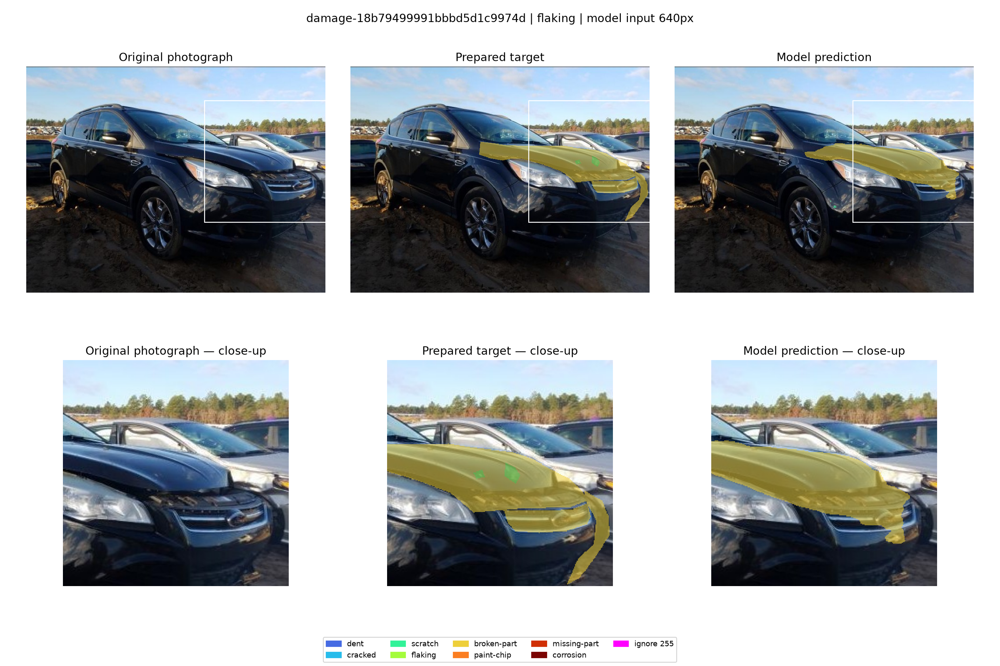

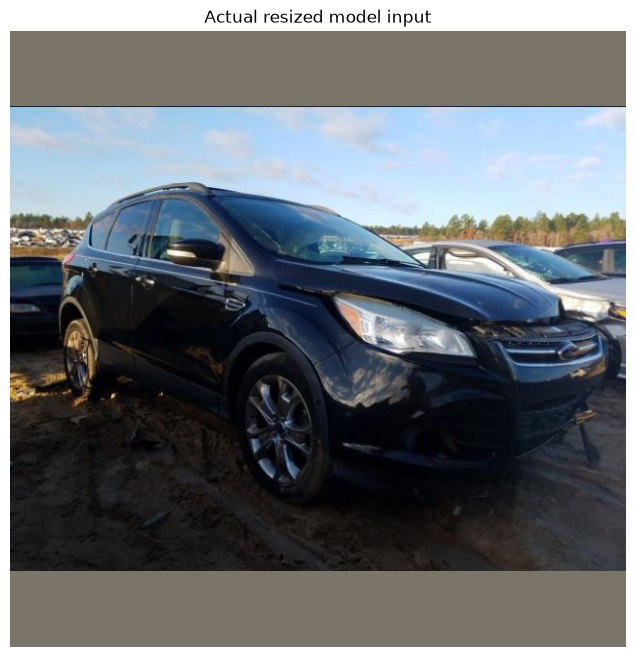

In [11]:
# Browse one exported page at a time. Increase PAGE and rerun.
# After a restart, rerun step 1 and set AUDIT_DIR to your existing review folder.
AUDIT_DIR = ROOT / "artifacts/diagnostics/m2/20261001T163333Z-train-f5c955"
PAGE = 0
review_path = AUDIT_DIR / "review.csv"
review = pd.read_csv(review_path, keep_default_na=False)
row = review.iloc[PAGE]
display(row[["sample_id", "focus_class", "recall", "source_image", "source_annotation", "review_status", "notes"]])
display(DisplayImage(filename=str(AUDIT_DIR / row.preview_file)))
# For an exact view of what the model received (no augmentation):
from pipelines.vision.training import SegmentationDataset
item = SegmentationDataset([lookup[row.sample_id]], saved_cfg, num_classes=len(names))[0]
rgb = item["pixel_values"].numpy().transpose(1, 2, 0) * np.asarray(saved_cfg.std) + np.asarray(saved_cfg.mean)
plt.figure(figsize=(8, 8)); plt.imshow(rgb.clip(0, 1)); plt.axis("off"); plt.title("Actual resized model input"); plt.show()

## 4. Select a small, reviewed training subset

Start with **4–8 distinct clean images**, covering both flaking and paint-chip, plus their ordinary background and other annotated damage. You do not need to fit all 24 reviewed images. This asks whether the model can memorize a few unambiguous examples before testing generalization.

If the audit used validation images, leave them in validation and repeat steps 1–3 with `AUDIT_SPLIT="train"` to obtain training examples. The selection below refuses validation/test IDs, unresolved reviews and mismatched label hashes. Do not duplicate a training image into a fabricated validation split; the diagnostic measures the same training images explicitly.

Fill in `APPROVED_IDS` yourself after saving the review CSV. A `clean` status is a human decision, never prefilled by the notebook.

In [12]:
review = pd.read_csv(AUDIT_DIR / "review.csv", keep_default_na=False)
display(review[review.review_status == "clean"][["sample_id", "focus_class", "review_status", "notes"]])
APPROVED_IDS = ["damage-0326e5c9e84c867b190a4b25",
                "damage-0605a6a4044031cd488f2451",
                "damage-07d5b425f01db9b69d56f1cb",
                "damage-17f5a30a5789d76582cd332c",
                "damage-762b841cfa6c4c3d87c099b3",
                "damage-7800841cabc3eebd7619a481",
                "damage-289c2b859d4b1f71ca1da962"]  # Paste 4–8 clean TRAIN sample IDs here, as quoted strings.
if APPROVED_IDS:
    tiny_records = reviewed_training_records(review, records, APPROVED_IDS)
    assert 2 <= len(tiny_records) <= 8, "Start with 2–8 images; 4–8 is recommended."
    for cid in focus_ids:
        assert any(r["pixel_counts"][cid] for r in tiny_records), f"Include {names[cid]}"
    print("Selected original training images:", len(tiny_records))
else:
    print("Review the exported images and CSV first; no fitting selection has been made.")

,sample_id,focus_class,review_status,notes
1,damage-0326e5c9e84c867b190a4b25,paint-chip,clean,
5,damage-0605a6a4044031cd488f2451,paint-chip,clean,
7,damage-07d5b425f01db9b69d56f1cb,paint-chip,clean,
13,damage-17f5a30a5789d76582cd332c,paint-chip,clean,
18,damage-762b841cfa6c4c3d87c099b3,flaking,clean,
20,damage-7800841cabc3eebd7619a481,flaking,clean,
21,damage-289c2b859d4b1f71ca1da962,paint-chip,clean,


Selected original training images: 7


## 5. Run the small fitting test manually

The test builds a **fresh pretrained model with the same architecture**, keeps all nine output labels, disables augmentation and weight decay, and uses constant learning rates. It evaluates the same fixed images every 25 optimizer steps. It does not use the main trainer's validation, scheduler or early stopping. Start with 200 updates; this is a diagnostic budget, not a convergence guarantee.

The image size stays the same as the reference run so scale is controlled. Check that focus labels survive resizing before fitting. Keep dropout as part of the model, and explicitly control BatchNorm below. Train and measure in float32 on the selected CUDA/MPS/CPU device. GPU memory use still depends on resolution and batch size.

Results live in a new diagnostic folder, not the model-comparison table. High same-image IoU proves neither validation performance nor readiness for deployment.

In [13]:
RUN_TINY_FIT = True  # Turn on only after reviewing and explicitly selecting training IDs.
STEPS = 200
if RUN_TINY_FIT:
    tiny_records = reviewed_training_records(review, records, APPROVED_IDS)
    assert 2 <= len(tiny_records) <= 8
    tiny_cfg = replace(saved_cfg, encoder_lr=1e-5, head_lr=1e-4, weight_decay=0.0,
        batch_size=2, accumulation_steps=1, pretrained=True,
        crop_mode="legacy", scale_range=(1.0, 1.0), rotation_degrees=0,
        horizontal_flip=0, brightness=0, contrast=0, saturation=0,
        repeat_factor_threshold=0, freeze_encoder_epochs=0,
        freeze_batchnorm=False if saved_cfg.architecture == "segformer" else True,
        lr_schedule="cosine_epoch", warmup_epochs=0, amp=False, workers=0)
    check_data = SegmentationDataset(tiny_records, tiny_cfg, num_classes=len(names))
    for cid in focus_ids:
        assert any(bool((check_data[i]["labels"] == cid).any()) for i in range(len(check_data))), f"{names[cid]} vanished; review resize first"
    # Release the reference model before allocating another model on the GPU.
    model.to("cpu")
    if device.type == "mps": torch.mps.empty_cache()
    if device.type == "cuda": torch.cuda.empty_cache()
    FIT_DIR = AUDIT_DIR / ("tiny-fit-" + uuid.uuid4().hex[:8])
    tiny_model, tiny_history = fit_tiny_subset(tiny_records, tiny_cfg, names, device, FIT_DIR,
        steps=STEPS, report_every=25, source_provenance={
            "audit": json.loads((AUDIT_DIR / "audit.json").read_text()),
            "review_csv_sha256": _file_hash(AUDIT_DIR / "review.csv")})
    review.to_csv(FIT_DIR / "review_snapshot.csv", index=False)
    print("Diagnostic artifacts:", FIT_DIR)
else:
    print("Tiny fitting is disabled. No model has been trained by this cell.")

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([9, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([9]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


step 0: same-image loss=2.5631, foreground mIoU=0.009429895778821256
step 25: same-image loss=1.5804, foreground mIoU=0.010396147612517143
step 50: same-image loss=1.0368, foreground mIoU=0.013710636601966536
step 75: same-image loss=0.7491, foreground mIoU=0.061699338956006385
step 100: same-image loss=0.6429, foreground mIoU=0.08382779007237777
step 125: same-image loss=0.6056, foreground mIoU=0.08645299592178186
step 150: same-image loss=0.5681, foreground mIoU=0.12360146636951344
step 175: same-image loss=0.5399, foreground mIoU=0.18578014006061075
step 200: same-image loss=0.5226, foreground mIoU=0.22313902709201178
Diagnostic artifacts: /Users/rodel/Projects/nus/CLAIM-CMEV/artifacts/diagnostics/m2/20261001T163333Z-train-f5c955/tiny-fit-dd4c4a7b


## 6. Read the diagnostic results

Inspect both the curves and masks. Seek a clear loss reduction and strong per-class fit on these same images; around 0.9 focus-class IoU is a useful aspiration for clean, resolvable examples, not a guaranteed threshold or a held-out acceptance target. Tiny regions, ambiguous boundaries and model output resolution can prevent a perfect fit.

| Observation | Next investigation |
| --- | --- |
| Focus labels disappear before the model sees them | Resolve resizing/crop resolution first. |
| Fits clean examples well, but normal validation remains poor | Investigate data diversity, annotation consistency, rare-pixel exposure and domain differences. More capacity alone may not help. |
| Loss stays flat or predictions remain background on the tiny set | Check label IDs, ignored pixels, normalization, gradients and learning rate; compare batch statistics in train/eval mode. |
| Loss improves but only tiny-class masks remain poor | Inspect per-class gradients/loss balance, boundaries and output resolution; test a detail-preserving decoder as a controlled alternative. |
| Reviews disagree on flaking versus paint-chip | Establish a consistent annotation convention before additional training. |

If the first 200 steps are inconclusive, change one factor and create another diagnostic run. Keep test data untouched; never present these same-image scores as generalization results.

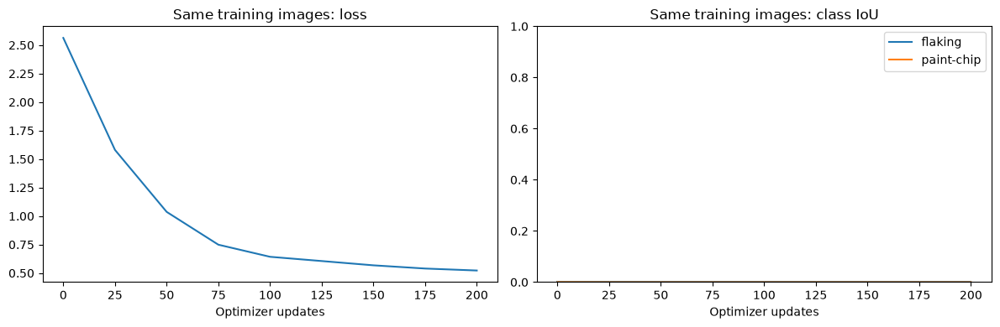

,class_id,class_name,iou,dice,precision,recall,support_pixels,predicted_pixels,iou_reason
0,0,background,0.970481,0.985019,0.983749,0.986293,1767033,1771602,None
1,1,dent,0.169819,0.290334,0.914923,0.172544,11655,2198,None
2,2,cracked,0.860594,0.925075,0.928905,0.921276,10594,10507,None
3,3,scratch,0.000000,0.000000,NaN,0.000000,9717,0,None
4,4,flaking,0.000000,0.000000,NaN,0.000000,258,0,None
5,5,broken-part,0.754699,0.860203,0.813871,0.912129,159894,179198,None
6,6,paint-chip,0.000000,0.000000,NaN,0.000000,1413,0,None
7,7,missing-part,0.000000,0.000000,NaN,0.000000,1929,0,None
8,8,corrosion,0.000000,0.000000,NaN,0.000000,1012,0,None


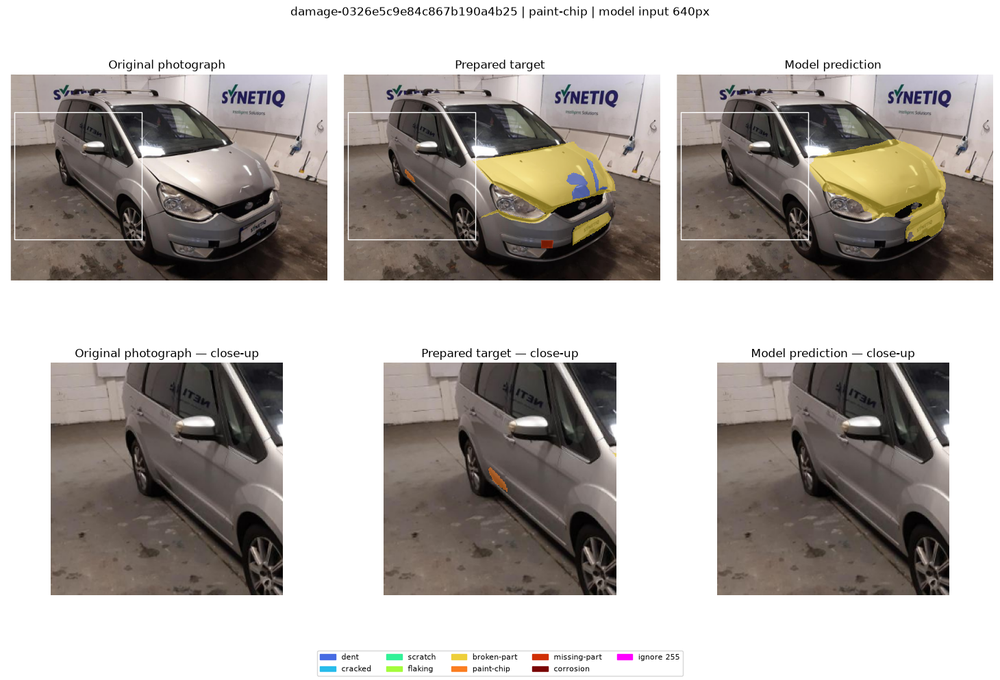

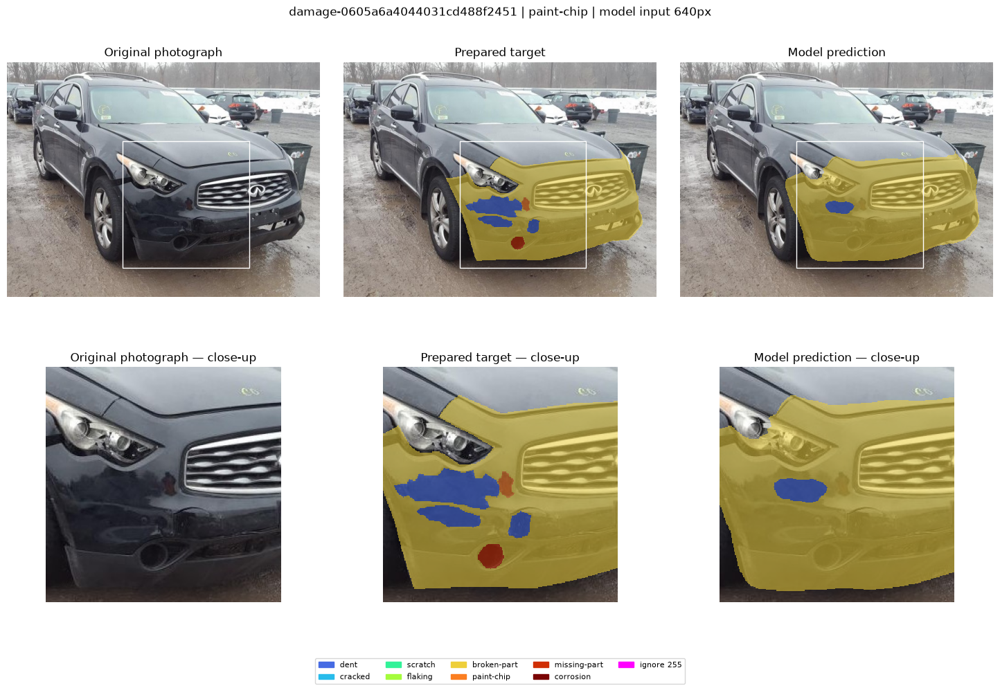

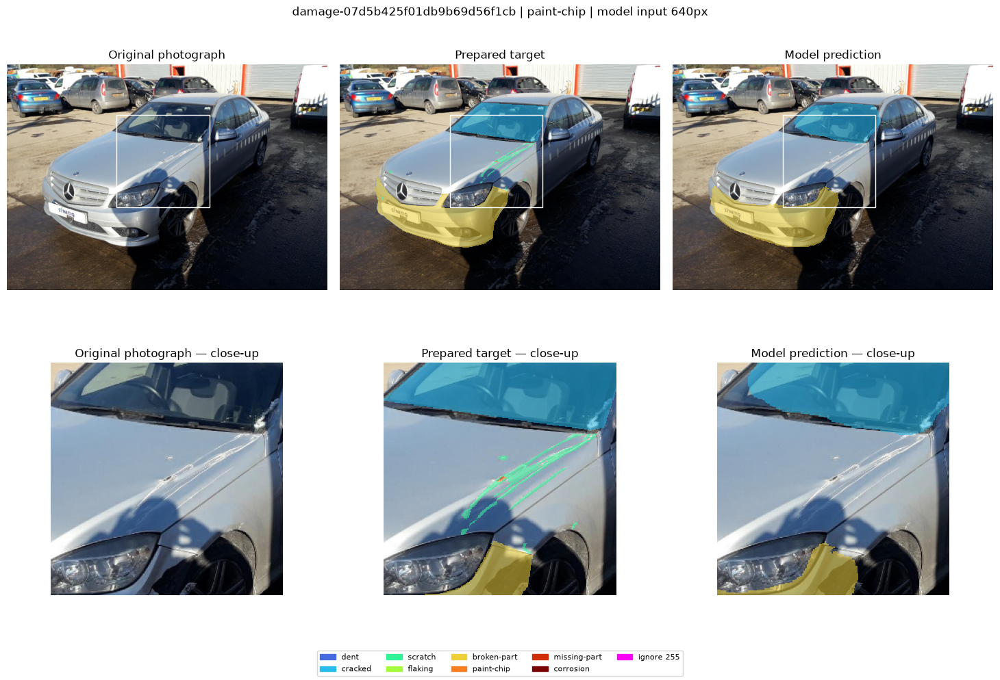

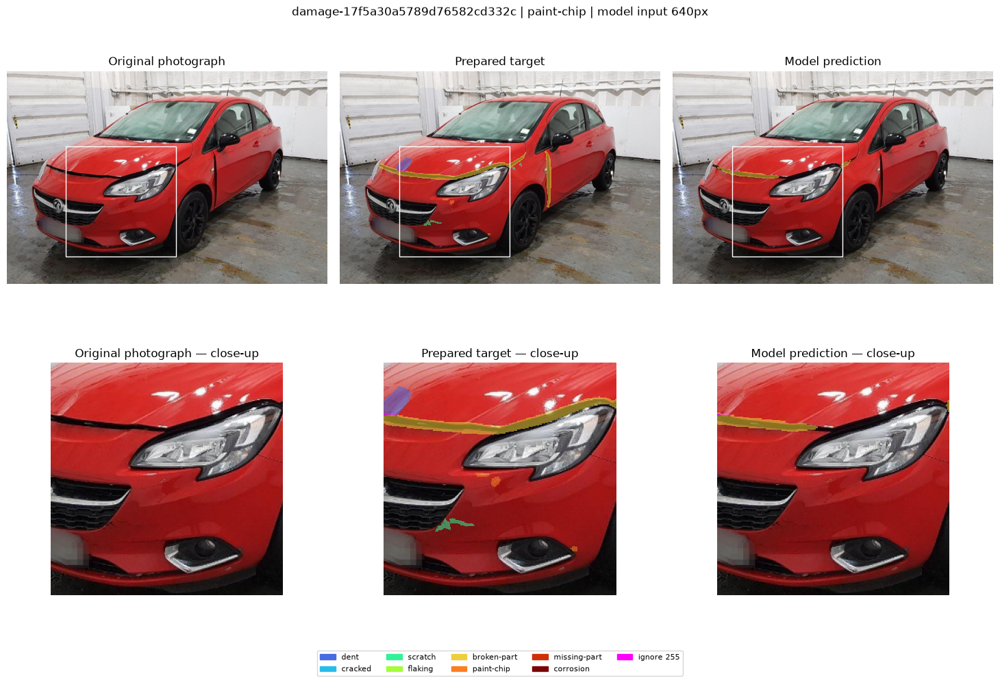

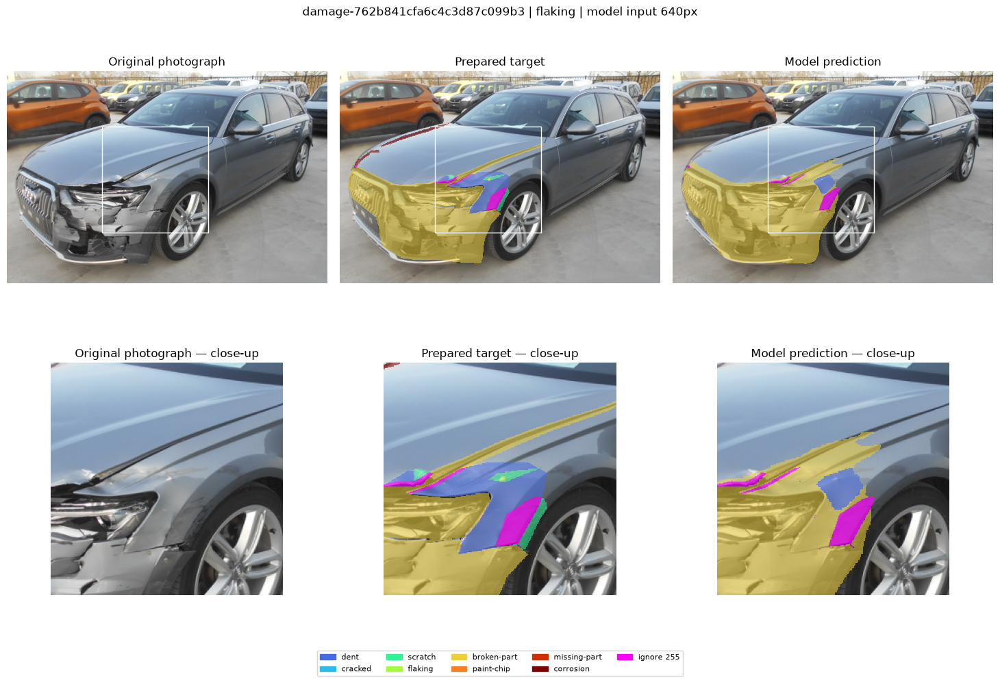

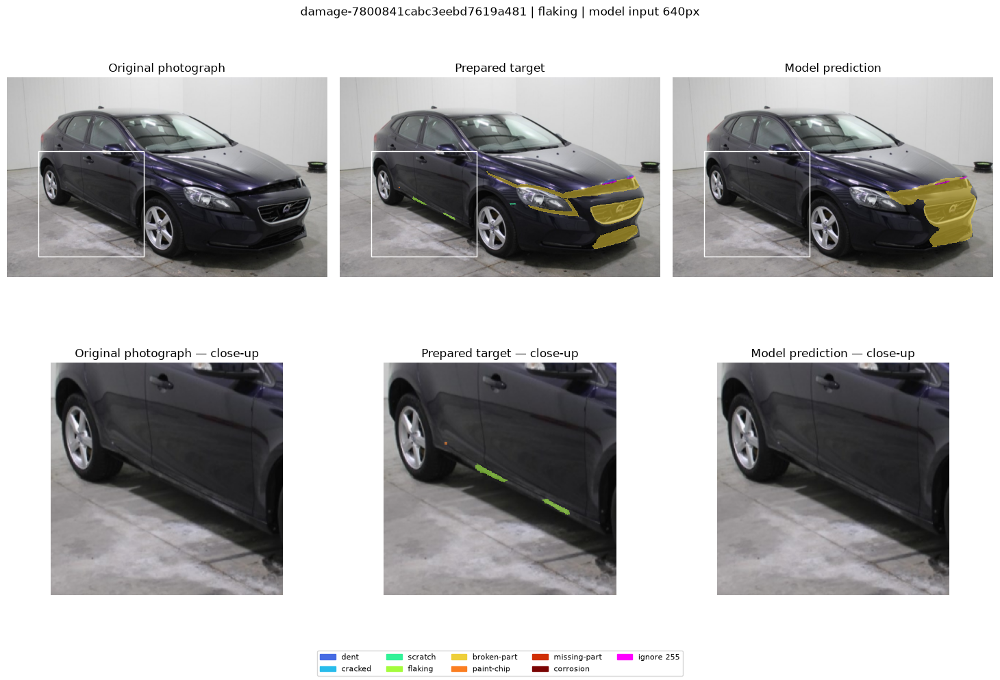

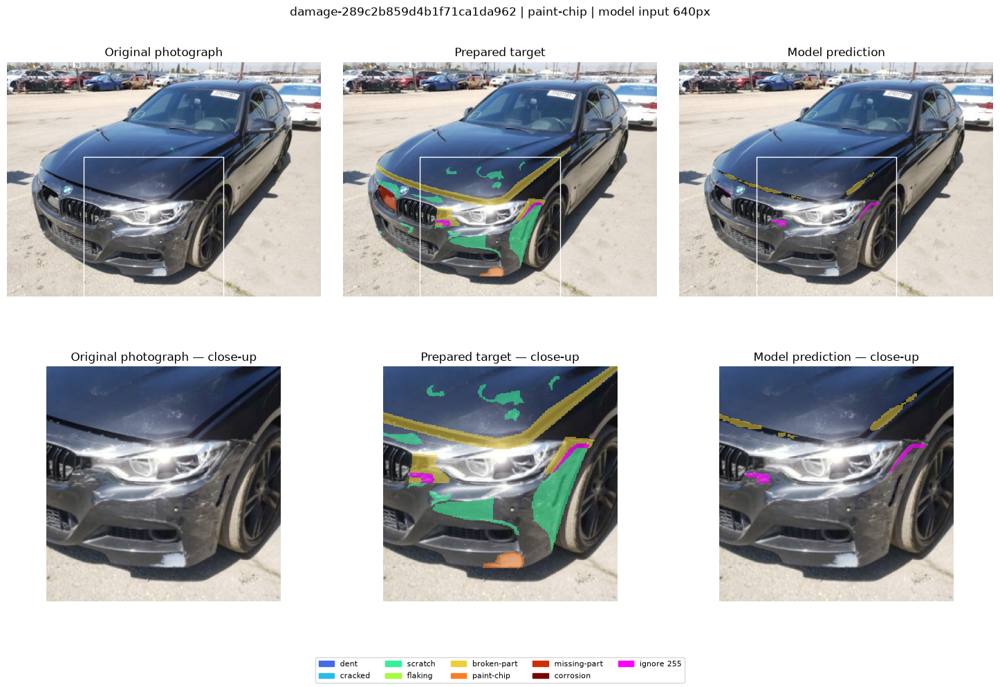

In [14]:
if RUN_TINY_FIT:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot([h["step"] for h in tiny_history], [h["loss"] for h in tiny_history])
    axes[0].set_title("Same training images: loss")
    for name in FOCUS_CLASSES:
        cid = names.index(name)
        axes[1].plot([h["step"] for h in tiny_history],
            [h["per_class"][cid]["iou"] for h in tiny_history], label=name)
    axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].set_title("Same training images: class IoU")
    for ax in axes: ax.set_xlabel("Optimizer updates")
    fig.tight_layout(); fig.savefig(FIT_DIR / "fit-curves.png", dpi=150); plt.show()
    display(pd.DataFrame(tiny_history[-1]["per_class"]))
    for i, record in enumerate(tiny_records):
        focus = next(n for n in FOCUS_CLASSES if record["pixel_counts"][names.index(n)])
        fig = render_review(tiny_model, record, tiny_cfg, names, device, focus)
        fig.savefig(FIT_DIR / f"fit-example-{i+1}.png", dpi=150); plt.show()
else:
    print("No fitting results yet.")